# Dataset Ingestion

In [3]:
#Data Loading:
import pandas as pd

columns = ["user_id", "item_id", "rating", "timestamp"]

ratings = pd.read_csv(
    "../data/raw/u.data",
    sep="\t",
    names=columns
)

# Exploratory Data Analysis

In [4]:
#Dataset Overview
print(ratings.shape)
print(ratings.info())

(100000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None


In [5]:
#Cardinality Analysis
num_users = ratings['user_id'].nunique()
num_items = ratings['item_id'].nunique()
num_interactions = len(ratings)

print(num_users, num_items, num_interactions)

943 1682 100000


In [6]:
#Sparsity (Key Theoretical Insight)
sparsity = 1 - (num_interactions / (num_users * num_items))
print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9370


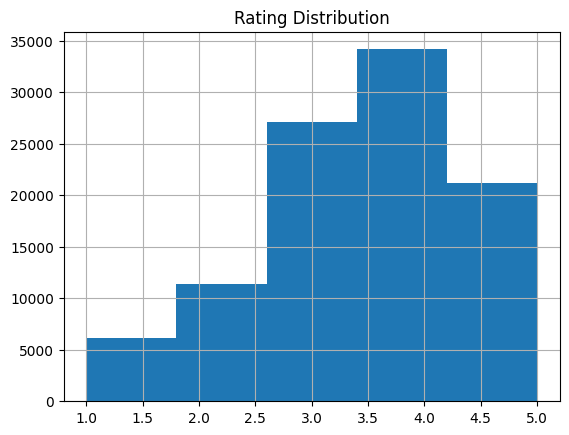

In [7]:
#Rating Distribution
import matplotlib.pyplot as plt

ratings['rating'].hist(bins=5)
plt.title("Rating Distribution")
plt.show()

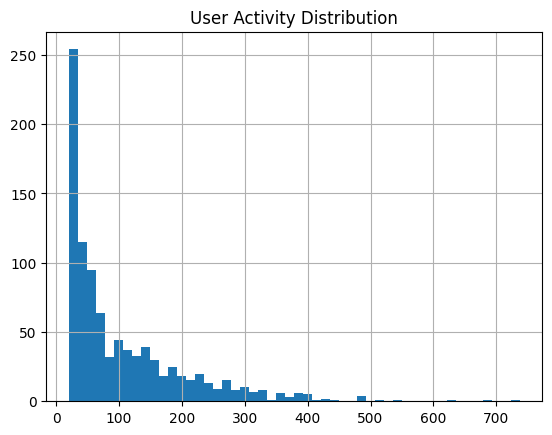

In [8]:
#User Activity Distribution
ratings.groupby('user_id').size().hist(bins=50)
plt.title("User Activity Distribution")
plt.show()

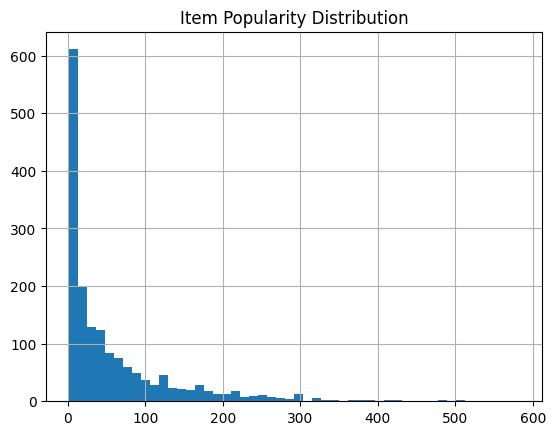

In [9]:
#Item Popularity (Critical for Bias)
ratings.groupby('item_id').size().hist(bins=50)
plt.title("Item Popularity Distribution")
plt.show()

In [ ]:
#Data Persistence
ratings.to_csv("../data/processed/ratings_clean.csv", index=False)